# SQLite & CoinMarketCap Example Notebook

In [17]:
%load_ext autoreload
%autoreload 2
%autosave 30

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosaving every 30 seconds


## Notebook Setup and Imports
This section sets up the notebook environment for efficient, interactive development and imports all necessary libraries for data fetching, manipulation, visualization, and storage.

In [18]:
# Import standard and third-party libraries for logging, HTTP requests, data handling, visualization, and database operations.
import logging
from requests import Request, Session
import pandas as pd
import sqlite3
import mplfinance as mpf
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sqlite_utils

# import helpers.hdbg as hdbg
# import helpers.hprint as hprint

## API Key and Endpoint Configuration
This section defines the API key and endpoint URLs for accessing live cryptocurrency data from CoinMarketCap. It also sets up request headers and parameters for API calls.

In [19]:
# hdbg.init_logger(verbosity=logging.INFO)
# _LOG = logging.getLogger(__name__)
# hprint.config_notebook()

In [20]:
# Set your CoinMarketCap API key.
API_KEY = # TO BE FILLED
# Define headers for API authentication and response format.
headers = {'X-CMC_PRO_API_KEY': API_KEY,'Accept': 'application/json'}

# Define the endpoint URL for fetching latest cryptocurrency listings.
url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'

# Set request parameters: limit results and specify currency conversion.
params = {'limit': 1,'convert': 'USD'}

# Set the date format string for consistent datetime parsing.
DATEFMT = "%Y-%m-%d-%H-%M-%S"


# Testing API and Functions

## Load Data
This section retrieves 15 years of daily historical Bitcoin (BTC-USD) data using a custom utility, then displays the shape and a preview of the dataset.

In [21]:
# Fetch 15 years of daily BTC-USD historical data using a custom sqlite_utils function.
data = sqlite_utils.fetchHistoricalBTC(ticker="BTC-USD", period='15y', interval='1d')

# Print the shape (rows, columns) of the retrieved data.
print(f"Shape of data: {data.shape}")

# Display the first five rows to inspect the structure and sample values.
data.head()


Shape of data: (3869, 6)


,date,close,high,low,open,volume
0,2014-09-17-00-00-00,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18-00-00-00,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19-00-00-00,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20-00-00-00,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21-00-00-00,398.821014,412.425995,393.181000,408.084991,26580100


In [22]:
data.tail()

,date,close,high,low,open,volume
3864,2025-04-16-00-00-00,84033.867188,85428.281250,83100.617188,83674.507812,29617804112
3865,2025-04-17-00-00-00,84895.750000,85449.070312,83749.750000,84030.671875,21276866029
3866,2025-04-18-00-00-00,84450.804688,85095.046875,84298.882812,84900.187500,12728372364
3867,2025-04-19-00-00-00,85063.414062,85597.703125,84353.460938,84450.867188,15259300427
3868,2025-04-20-00-00-00,84354.257812,85291.500000,84012.218750,85071.359375,14650147840


## Storing Data into SQLite
This section stores the fetched historical Bitcoin data into a local SQLite database for persistent storage and future queries.

In [23]:
%%time
# Store the DataFrame into a local SQLite database file named 'btcDaily.db'.
sqlite_utils.storeData(data=data, db="./btcDaily.db")

CPU times: user 4.46 ms, sys: 1.68 ms, total: 6.13 ms
Wall time: 5.87 ms


## Querying Data from SQLite Database

This section retrieves the stored Bitcoin daily statistics from the SQLite database to verify storage and enable further analysis.

In [24]:
# Define SQL query to select all records from the btc_daily_stats table.
query = "SELECT * FROM btc_daily_stats"

# Fetch the data from the database.
data = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")

In [25]:
print(f"Shape of data: {data.shape}")
data.head()

Shape of data: (3869, 6)


,date,close,high,low,open,volume
0,2014-09-17-00-00-00,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18-00-00-00,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19-00-00-00,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20-00-00-00,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21-00-00-00,398.821014,412.425995,393.181000,408.084991,26580100


## Fetching and Displaying Live Bitcoin Data

This section fetches the latest live Bitcoin data and auxiliary statistics from the CoinMarketCap API, then prints the results for immediate inspection.

In [26]:
# Define the endpoint for live Bitcoin quotes.
url = 'https://pro-api.coinmarketcap.com/v2/cryptocurrency/quotes/latest'

# Fetch live Bitcoin data and additional statistics using a custom utility.
btcLiveData, btcAuxData = sqlite_utils.liveBTC(url=url, API_KEY=API_KEY)

In [27]:
# Print the main live Bitcoin status (date, open price, volume).
print("Live Bitcoin Status:\n", btcLiveData)

Live Bitcoin Status:
 {'date': '2025-04-20-16-00-00', 'open': 84354.26153760457, 'volume': 14650147856.034328}


In [28]:
# Print additional details such as price changes, market cap, and dominance.
print("Live Bitcoin Additional Details:\n", btcAuxData)

Live Bitcoin Additional Details:
 {'price': 84354.26153760457, 'volume_24h': 14650147856.034328, 'volume_change_24h': 10.543, 'percent_change_1h': -0.32330449, 'percent_change_24h': -0.95285339, 'percent_change_7d': 0.57641525, 'percent_change_30d': 1.00243766, 'percent_change_60d': -12.14983814, 'percent_change_90d': -19.76381031, 'market_cap': 1674764194249.1243, 'market_cap_dominance': 62.9365, 'fully_diluted_market_cap': 1771439492289.7, 'tvl': None, 'last_updated': '2025-04-20T16:00:00.000Z'}


## Adding Live Data Point to Database
This section appends the latest live Bitcoin data point to the existing SQLite database, ensuring the dataset remains up to date.

In [29]:
# Add the latest live data point to the local SQLite database.
sqlite_utils.addDatapoint(liveData=btcLiveData, db="./btcDaily.db")

# Analysis

In [30]:
query = "SELECT * FROM btc_daily_stats"
data = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")

print(f"Shape of data: {data.shape}")

data.tail()

Shape of data: (3870, 6)


,date,close,high,low,open,volume
3865,2025-04-17-00-00-00,84895.750000,85449.070312,83749.750000,84030.671875,2.127687e+10
3866,2025-04-18-00-00-00,84450.804688,85095.046875,84298.882812,84900.187500,1.272837e+10
3867,2025-04-19-00-00-00,85063.414062,85597.703125,84353.460938,84450.867188,1.525930e+10
3868,2025-04-20-00-00-00,84354.257812,85291.500000,84012.218750,85071.359375,1.465015e+10
3869,2025-04-20-16-00-00,NaN,NaN,NaN,84354.261538,1.465015e+10


## Bitcoin Open Price

A line plot visualizes the daily opening price of Bitcoin across the full historical range. The most recent opening price is highlighted with a red star to emphasize the latest market value.

_The plot shows a dramatic long-term uptrend with significant volatility._

In [31]:
# Convert the 'date' column to pandas datetime for time series analysis.
data['date'] = pd.to_datetime(data['date'], format=DATEFMT)

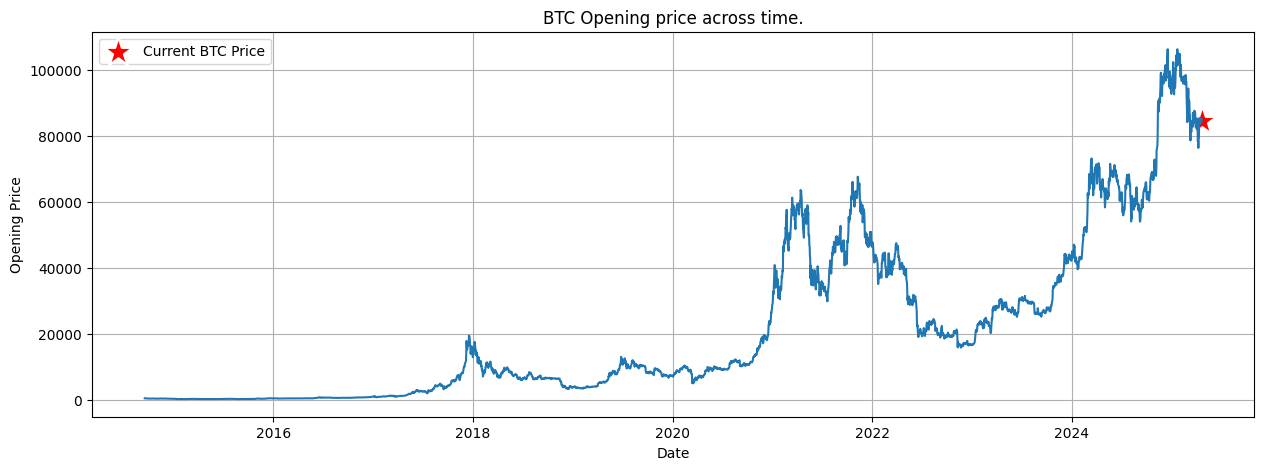

In [32]:
# Plot Opening Price of BTC.

plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=data, x='date', y='open')
sns.scatterplot(x=[data.iloc[-1]['date']], y=[data.iloc[-1]['open']], s=500, marker='*', color='red', label='Current BTC Price') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Opening Price")
plt.title("BTC Opening price across time.")
plt.show()

### Moving Average

In [33]:
# Query moving averages (2d, 30d, 120d) for opening price from the database.
query = '''SELECT 
    date,
    open,
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_open, --Adding 2 Day Moving Average
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_open, --Adding 30 Day Moving Average
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_open --Adding 120 Day Moving Average
FROM btc_daily_stats
ORDER BY date;
'''
dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,open,ma_2d_open,ma_30d_open,ma_120d_open
3865,2025-04-17 00:00:00,84030.671875,83852.59,83574.74,92238.76
3866,2025-04-18 00:00:00,84900.187500,84465.43,83647.46,92112.34
3867,2025-04-19 00:00:00,84450.867188,84675.53,83566.72,92003.72
3868,2025-04-20 00:00:00,85071.359375,84761.11,83596.95,91898.01
3869,2025-04-20 16:00:00,84354.261538,84712.81,83607.21,91790.81


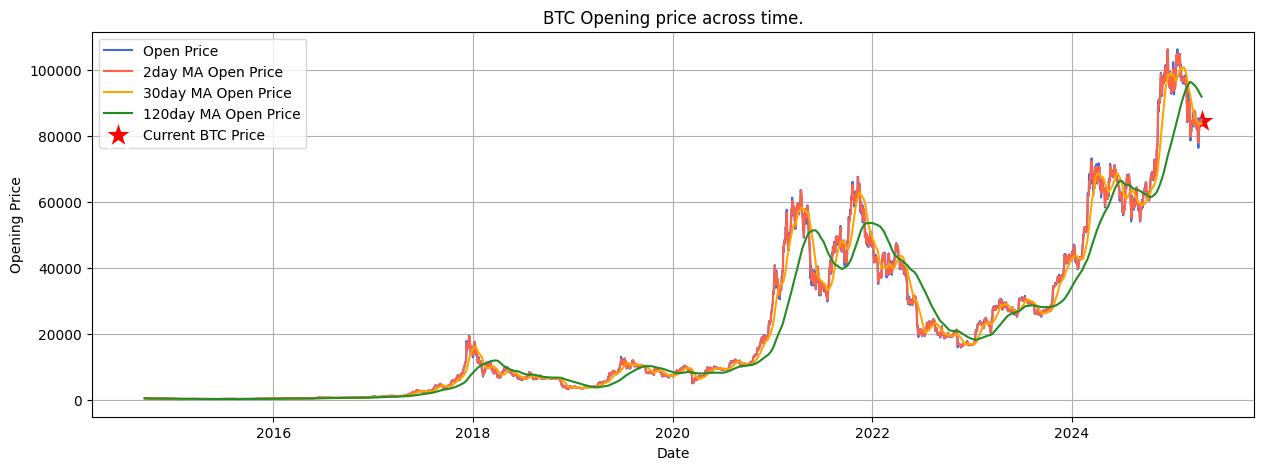

In [34]:
# Plot moving averages.

plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='open', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_open', label='2day MA Open Price', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_open', label='30day MA Open Price', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_open', label='120day MA Open Price', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['open']], s=500, marker='*', color='red', label='Current BTC Price') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Opening Price")
plt.title("BTC Opening price across time.")
plt.show()

### Moving Average - Data Range

In [35]:
# Query moving averages (2d, 30d, 120d) for opening price from the database in a particular date range. 

dateStart, dateEnd = '2024-12-24-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_open,
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_open,
    
    ROUND(AVG(open) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_open
FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}' --Adding Date Range
ORDER BY date;
'''

dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,open,ma_2d_open,ma_30d_open,ma_120d_open
108,2025-04-11,79625.046875,81095.51,83412.15,92444.02
109,2025-04-12,83404.515625,81514.78,83401.47,92361.84
110,2025-04-13,85279.468750,84341.99,83541.89,92298.04
111,2025-04-14,83694.523438,84487.00,83532.76,92221.22
112,2025-04-15,84539.695312,84117.11,83539.64,92153.24


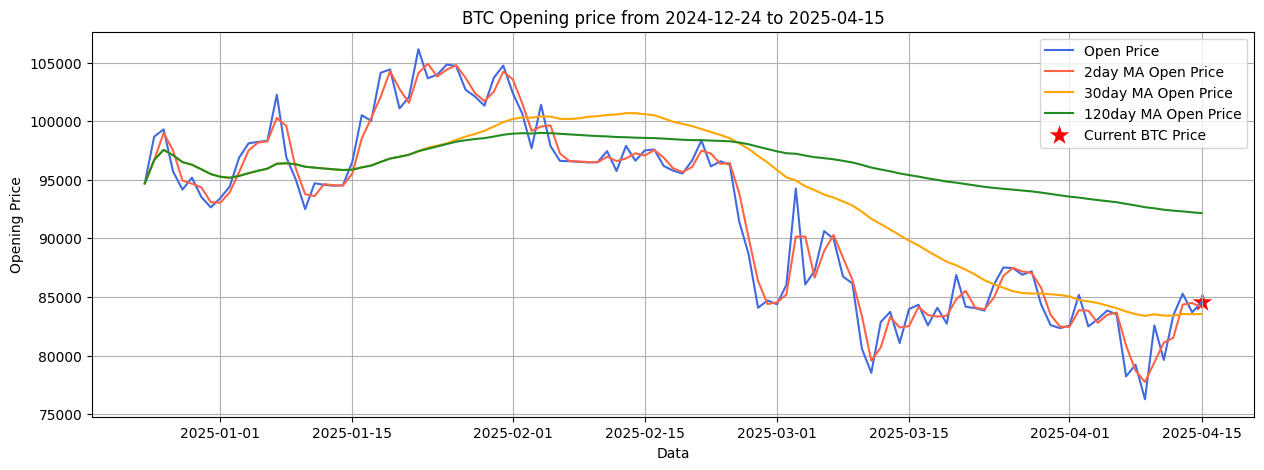

In [36]:
# Plot moving averages in a daterange

plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='open', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_open', label='2day MA Open Price', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_open', label='30day MA Open Price', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_open', label='120day MA Open Price', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['open']], s=400, marker='*', color='red', label='Current BTC Price') 
plt.grid(True)
plt.xlabel("Data")
plt.ylabel("Opening Price")

plt.title(f"BTC Opening price from {dateStart[:10]} to {dateEnd[:10]}")
plt.show()

## Bitcoin Volume
A line plot displays daily trading volume alongside its 2-day, 30-day, and 120-day moving averages. This analysis reveals periods of heightened trading activity and liquidity.
* Volume spikes often coincide with sharp price movements, indicating increased trader participation during volatile periods.
* The 120-day MA shows a general long-term decline in volume after peaks, but recent months have seen renewed activity.

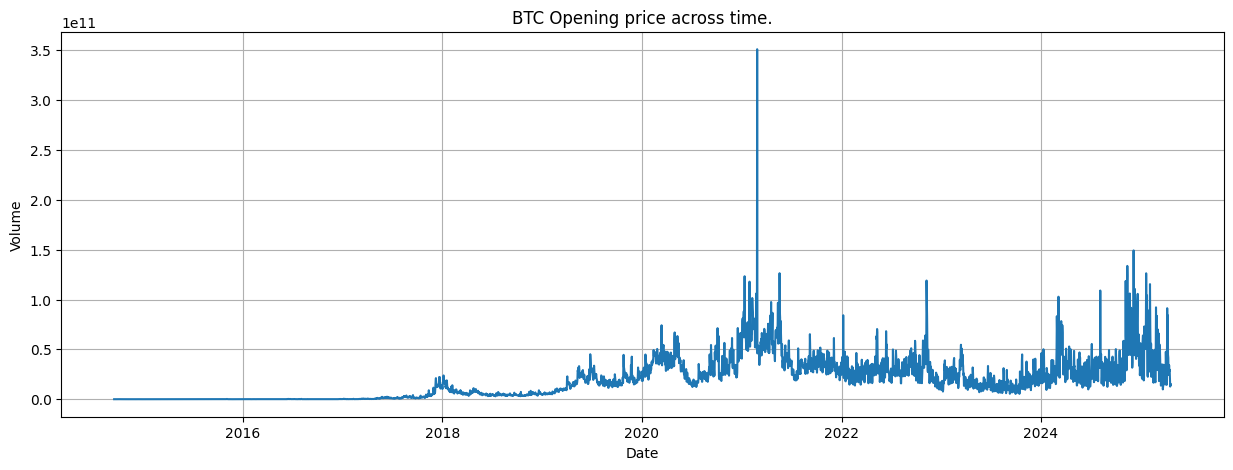

In [37]:
# Plot trading volume of BTC.

plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=data, x='date', y='volume')
plt.title("BTC Opening price across time.")
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

### Moving average

In [38]:
# Query and plot moving averages for BTC trading volume.
query = '''SELECT 
    date,
    volume,
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_vol, --Adding 2 Day Moving Average
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_vol, --Adding 30 Day Moving Average
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_vol --Adding 120 Day Moving Average
FROM btc_daily_stats
ORDER BY date;
'''
dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,volume,ma_2d_vol,ma_30d_vol,ma_120d_vol
3865,2025-04-17 00:00:00,2.127687e+10,2.544734e+10,3.335943e+10,4.464252e+10
3866,2025-04-18 00:00:00,1.272837e+10,1.700262e+10,3.261931e+10,4.393841e+10
3867,2025-04-19 00:00:00,1.525930e+10,1.399384e+10,3.216032e+10,4.318528e+10
3868,2025-04-20 00:00:00,1.465015e+10,1.495472e+10,3.201431e+10,4.287599e+10
3869,2025-04-20 16:00:00,1.465015e+10,1.465015e+10,3.217387e+10,4.263851e+10


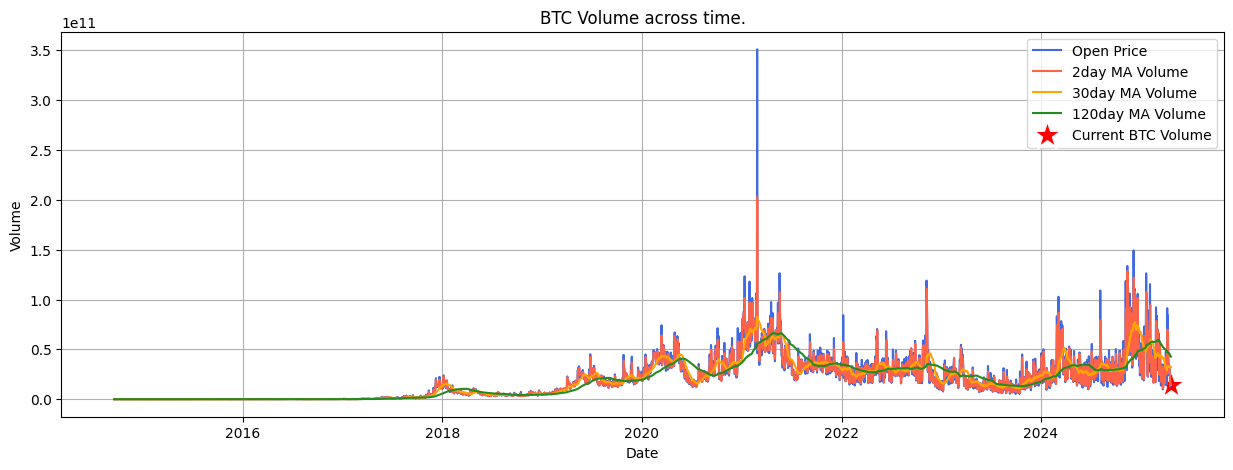

In [39]:
# Plot moving averages for BTC trading volume.

plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='volume', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_vol', label='2day MA Volume', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_vol', label='30day MA Volume', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_vol', label='120day MA Volume', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['volume']], s=500, marker='*', color='red', label='Current BTC Volume') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Volume")

plt.title("BTC Volume across time.")
plt.show()

### Moving Average - Data Range

In [40]:
# Query moving averages (2d, 30d, 120d) for volume from the database in a particular date range. 


dateStart, dateEnd = '2024-12-24-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    volume,
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ), 2) AS ma_2d_vol,
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS ma_30d_vol,
    
    ROUND(AVG(volume) OVER (
        ORDER BY date 
        ROWS BETWEEN 119 PRECEDING AND CURRENT ROW
    ), 2) AS ma_120d_vol
FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}' --Adding Date Range
ORDER BY date;
'''

dataMA = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataMA['date'] = pd.to_datetime(dataMA['date'], format=DATEFMT)
dataMA.tail()

,date,volume,ma_2d_vol,ma_30d_vol,ma_120d_vol
108,2025-04-11,41656778779,4.318739e+10,3.266242e+10,4.429370e+10
109,2025-04-12,24258059104,3.295742e+10,3.242392e+10,4.411156e+10
110,2025-04-13,28796984817,2.652752e+10,3.239755e+10,4.397359e+10
111,2025-04-14,34090769777,3.144388e+10,3.307889e+10,4.388535e+10
112,2025-04-15,28040322885,3.106555e+10,3.330256e+10,4.374513e+10


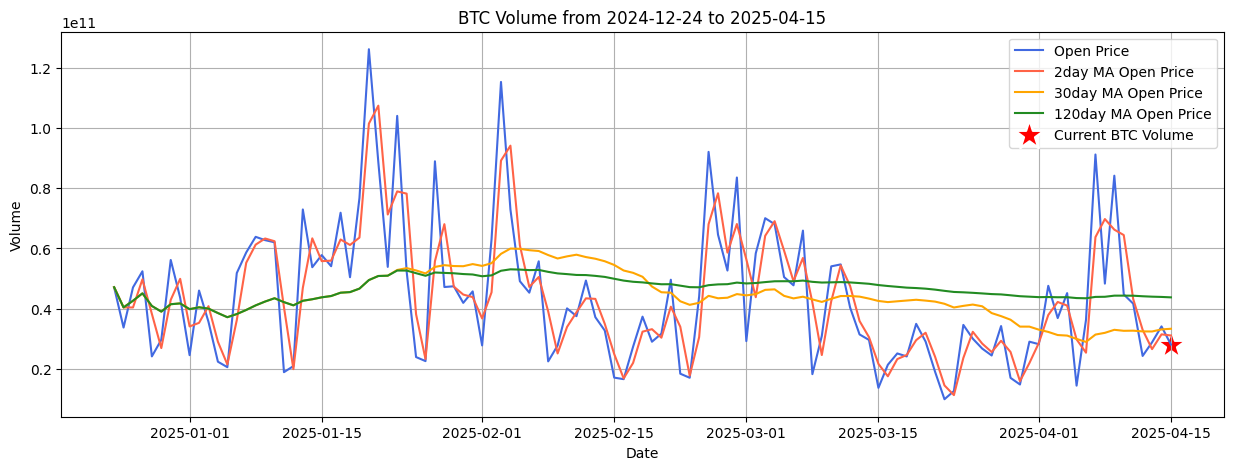

In [41]:
plt.figure(figsize=(15,5), dpi=100)
sns.lineplot(data=dataMA, x='date', y='volume', label='Open Price', color='royalblue')
sns.lineplot(data=dataMA, x='date', y='ma_2d_vol', label='2day MA Open Price', color='tomato')
sns.lineplot(data=dataMA, x='date', y='ma_30d_vol', label='30day MA Open Price', color='orange')
sns.lineplot(data=dataMA, x='date', y='ma_120d_vol', label='120day MA Open Price', color='forestgreen')

sns.scatterplot(x=[dataMA.iloc[-1]['date']], y=[dataMA.iloc[-1]['volume']], s=500, marker='*', color='red', label='Current BTC Volume') 
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Volume")

plt.title(f"BTC Volume from {dateStart[:10]} to {dateEnd[:10]}")
plt.show()

## Candlestick/Bollinger Bands Analysis Plot

Bollinger Bands are calculated using a 20-day simple moving average (SMA) and standard deviation to define upper and lower bounds. A candlestick chart with overlaid Bollinger Bands is plotted to assess price volatility and potential overbought/oversold conditions.
* The price frequently touches or exceeds the upper band during strong rallies, indicating potential overbought conditions.

In [42]:
dateStart, dateEnd = '2024-08-24-00-00-00', '2025-04-15-00-00-00'

query = f"SELECT * FROM btc_daily_stats WHERE date BETWEEN '{dateStart}' AND '{dateEnd}' --Adding Date Range"
dataCS = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")

dataCS['date'] = pd.to_datetime(dataCS['date'], format=DATEFMT)

In [43]:
# Calculate 20-day Simple Moving Average and Bollinger Bands.

dataCS['SMA'] = dataCS.open.rolling(window=20).mean()
dataCS['stddev'] = dataCS.open.rolling(window=20).std()
dataCS['upper'] = dataCS.SMA + 2 * dataCS.stddev
dataCS['lower'] = dataCS.SMA - 2 * dataCS.stddev
dataCS.set_index('date', inplace=True)

tcdf = dataCS[['lower','upper','SMA']]

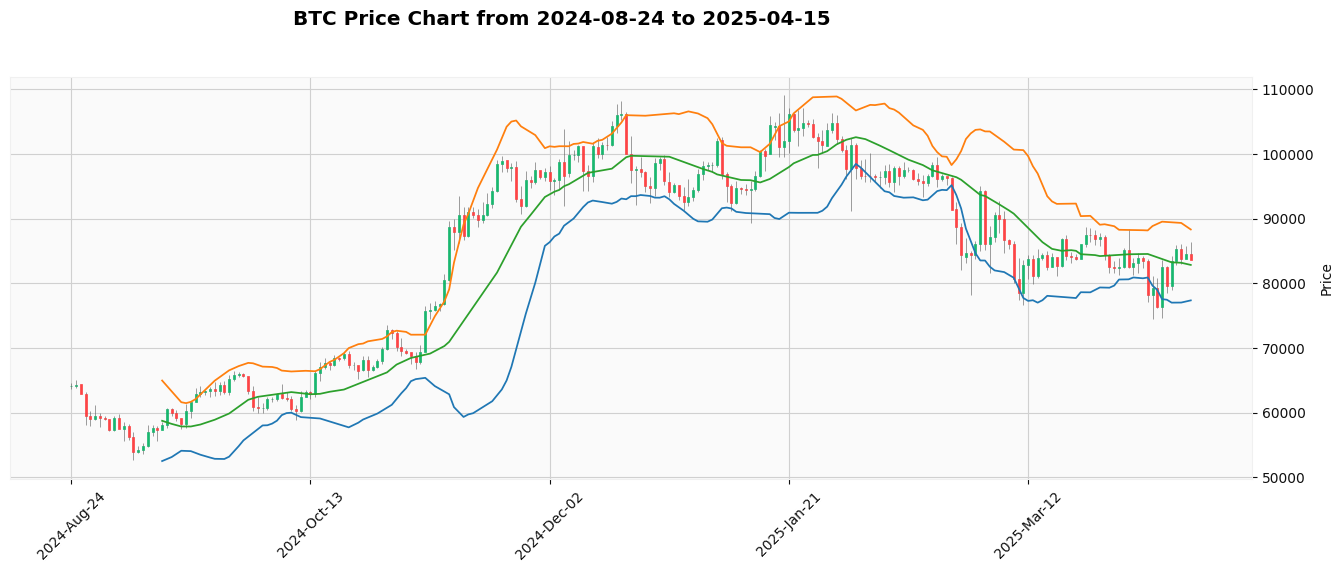

In [44]:
# Plot candlestick chart with Bollinger Bands.
apd = mpf.make_addplot(tcdf)
mpf.plot(dataCS, figratio=(15,5), type='candle', addplot=apd, volume=False, style='yahoo',title=f'BTC Price Chart from {dateStart[:10]} to {dateEnd[:10]}')

## Rate Of Change
This section computes the 1-day, 30-day, and 120-day percentage rate of change in the opening price, visualized as color-coded bar plots. Positive changes are green, negatives are red.

* The 1-day ROC is highly volatile, with frequent sharp swings both positive and negative.
* The 30-day ROC shows clusters of positive momentum during bull runs and negative during corrections.
* The 120-day ROC, while smoother, currently remains negative, indicating that despite recent highs, the price is below its level four months ago.

In [45]:
# Calculate 1, 30, and 120-day rate of change for BTC opening price.

dateStart, dateEnd = '2024-12-01-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    -- 1-day Rate of Change
    ROUND(((open - LAG(open, 1) OVER (ORDER BY date)) / LAG(open, 1) OVER (ORDER BY date)) * 100, 2) AS roc_1d,

    -- 30-day Rate of Change
    ROUND(((open - LAG(open, 30) OVER (ORDER BY date)) / LAG(open, 30) OVER (ORDER BY date)) * 100, 2) AS roc_30d,

    -- 120-day Rate of Change
    ROUND(((open - LAG(open, 120) OVER (ORDER BY date)) / LAG(open, 120) OVER (ORDER BY date)) * 100, 2) AS roc_120d

FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}'
ORDER BY date'''

dataRC = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataRC['date'] = pd.to_datetime(dataRC['date'], format=DATEFMT)

dataRC.tail()

,date,open,roc_1d,roc_30d,roc_120d
131,2025-04-11,79625.046875,-3.56,-3.90,-21.29
132,2025-04-12,83404.515625,4.75,-0.38,-16.63
133,2025-04-13,85279.468750,2.25,5.20,-15.94
134,2025-04-14,83694.523438,-1.86,-0.33,-17.44
135,2025-04-15,84539.695312,1.01,0.24,-18.94


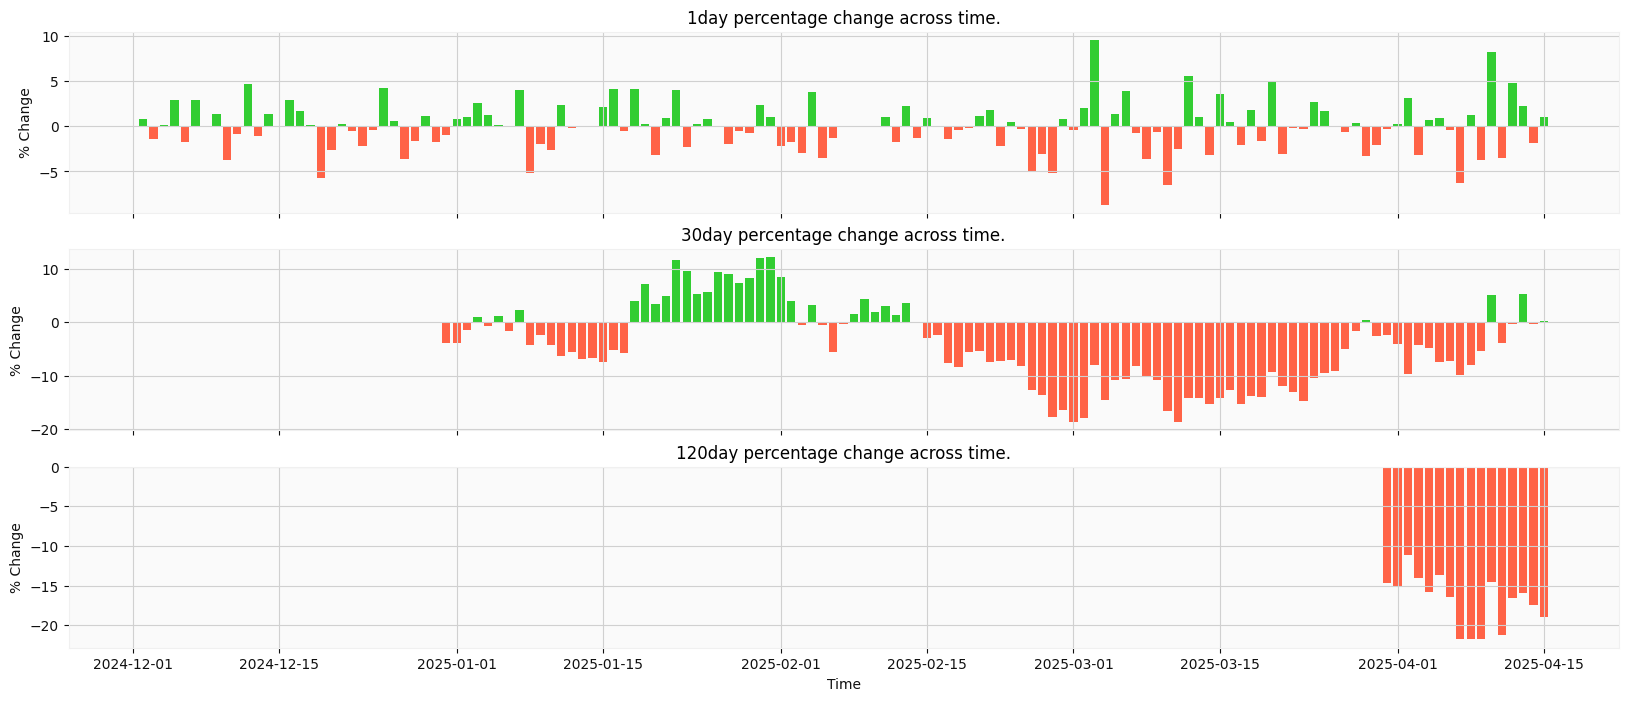

In [46]:
# Visualize short, medium, and long-term price momentum using color-coded bar plots.
f, ax = plt.subplots(nrows=3,ncols=1, figsize=(20,8), sharex=True)

colors = ['tomato' if val <=0 else 'limegreen' for val in dataRC['roc_1d']]
ax[0].bar(x=dataRC['date'], height=dataRC['roc_1d'], color=colors)
ax[0].set_title("1day percentage change across time.")
ax[0].set_ylabel("% Change")

colors = ['tomato' if val <=0 else 'limegreen' for val in dataRC['roc_30d']]
ax[1].bar(x=dataRC['date'], height=dataRC['roc_30d'], color=colors)
ax[1].set_title("30day percentage change across time.")
ax[1].set_ylabel("% Change")

colors = ['tomato' if val <=0 else 'limegreen' for val in dataRC['roc_120d']]
ax[2].bar(x=dataRC['date'], height=dataRC['roc_120d'], color=colors)
ax[2].set_title("120day percentage change across time.")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("% Change")

plt.show()

## Volatility
Volatility is estimated as the rolling standard deviation of daily returns over 5-day, 30-day, and 120-day windows. The results are plotted to visualize changes in market risk and turbulence.

* Short-term (2D) volatility spikes during major price moves, then subsides during sideways markets.
* Medium- and long-term volatility (30D, 120D) smooth out short-term noise but still reflect periods of sustained turbulence.

In [47]:
dateStart, dateEnd = '2024-04-01-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    -- 1-day Rate of Change
    ROUND(((open - LAG(open, 1) OVER (ORDER BY date)) / LAG(open, 1) OVER (ORDER BY date)) * 100, 2) AS roc_1d,

    -- 30-day Rate of Change
    ROUND(((open - LAG(open, 30) OVER (ORDER BY date)) / LAG(open, 30) OVER (ORDER BY date)) * 100, 2) AS roc_30d,

    -- 120-day Rate of Change
    ROUND(((open - LAG(open, 120) OVER (ORDER BY date)) / LAG(open, 120) OVER (ORDER BY date)) * 100, 2) AS roc_120d

FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}'
ORDER BY date'''

dataV = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataV['date'] = pd.to_datetime(dataV['date'], format=DATEFMT)

In [48]:
# Compute rolling volatility using standard deviation of daily returns for different window sizes.
dataV['daily_return'] = dataV['open'].pct_change()
dataV['volatility_2d'] = dataV['daily_return'].rolling(window=5).std()
dataV['volatility_30d'] = dataV['daily_return'].rolling(window=30).std()
dataV['volatility_120d'] = dataV['daily_return'].rolling(window=120).std()

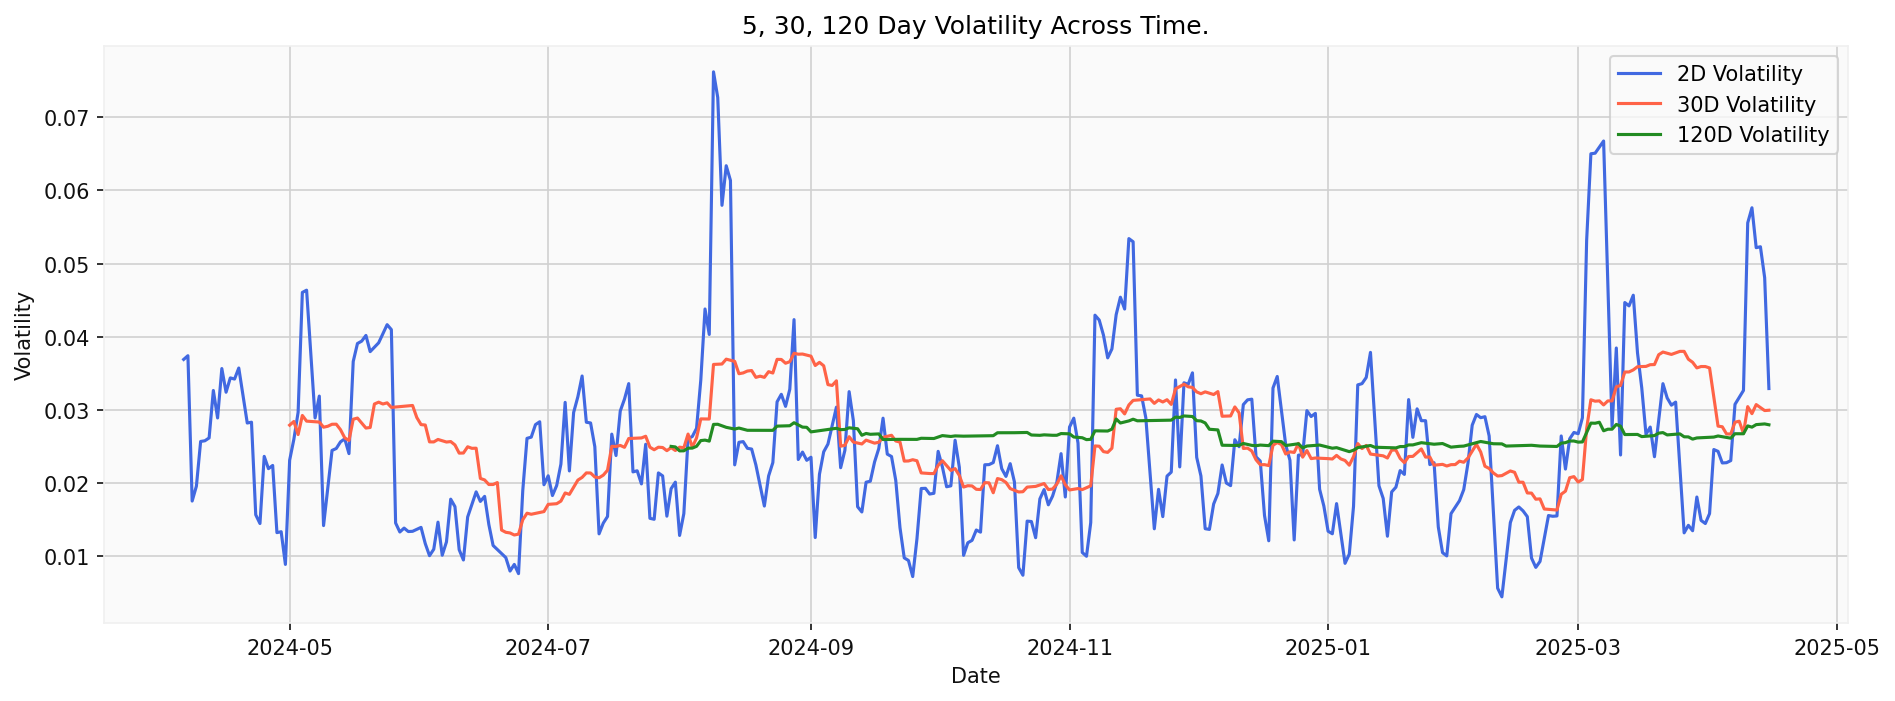

In [49]:
# Visualize short, medium, and long-term volatility trends to assess risk and market stability.

plt.figure(figsize=(15,5), dpi=150)
sns.lineplot(data=dataV, x='date', y='volatility_2d', label='2D Volatility', color='royalblue')
sns.lineplot(data=dataV, x='date', y='volatility_30d', label='30D Volatility', color='tomato')
sns.lineplot(data=dataV, x='date', y='volatility_120d', label='120D Volatility', color='forestgreen')
plt.title("5, 30, 120 Day Volatility Across Time.")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

## Histogram of Daily Records
A histogram displays the distribution of daily returns, with vertical lines marking the mean and median. This helps assess the skewness and typical magnitude of daily price changes.
* The distribution is centered slightly above zero, indicating a small positive drift over time.
* There is a long right tail, reflecting occasional large positive jumps.
* The mean is greater than the median, confirming positive skewness—consistent with the overall upward trend in BTC price

In [50]:
dateStart, dateEnd = '2024-04-01-00-00-00', '2025-04-15-00-00-00'

query = f'''SELECT 
    date,
    open,
    -- 1-day Rate of Change
    ROUND(((open - LAG(open, 1) OVER (ORDER BY date)) / LAG(open, 1) OVER (ORDER BY date)) * 100, 2) AS roc_1d,

    -- 30-day Rate of Change
    ROUND(((open - LAG(open, 30) OVER (ORDER BY date)) / LAG(open, 30) OVER (ORDER BY date)) * 100, 2) AS roc_30d,

    -- 120-day Rate of Change
    ROUND(((open - LAG(open, 120) OVER (ORDER BY date)) / LAG(open, 120) OVER (ORDER BY date)) * 100, 2) AS roc_120d

FROM btc_daily_stats
WHERE date BETWEEN '{dateStart}' AND '{dateEnd}'
ORDER BY date'''

dataV = sqlite_utils.fetchDB(query=query, db="./btcDaily.db")
dataV['date'] = pd.to_datetime(dataV['date'], format=DATEFMT)

In [51]:
dataV['daily_return'] = dataV['open'].pct_change()
dataV['volatility_2d'] = dataV['daily_return'].rolling(window=5).std()
dataV['volatility_30d'] = dataV['daily_return'].rolling(window=30).std()
dataV['volatility_120d'] = dataV['daily_return'].rolling(window=120).std()

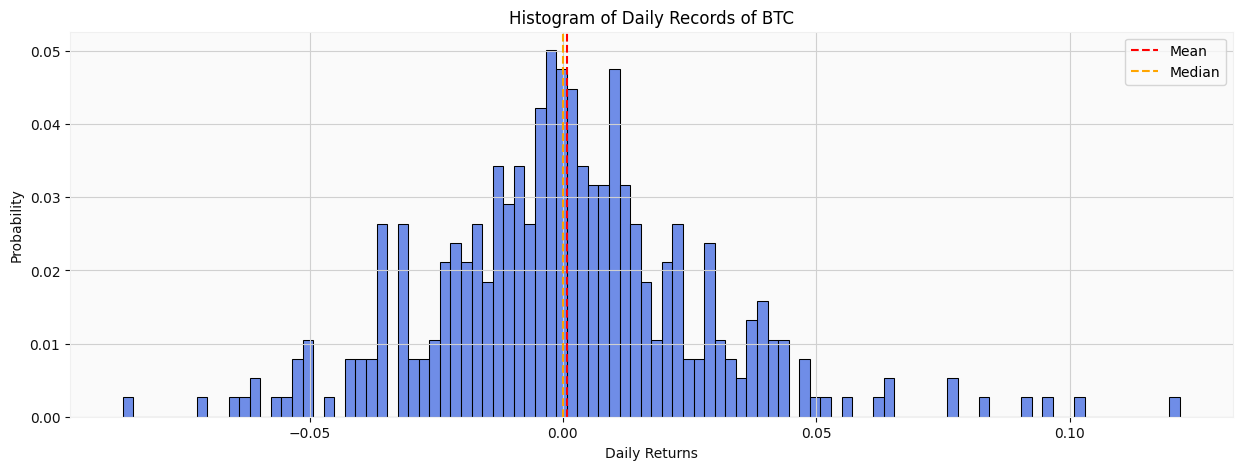

In [52]:
# Plot the distribution of daily returns to understand the return profile and detect skewness or outliers.

plt.figure(figsize=(15,5), dpi=100)
sns.histplot(data=dataV['daily_return'].dropna(), color='royalblue', bins=100, stat='probability',edgecolor='black')
plt.axvline(x = dataV['daily_return'].dropna().mean(), color ='red', linestyle ="--",linewidth=1.5, label = 'Mean') 
plt.axvline(x = dataV['daily_return'].dropna().median(), color ='orange', linestyle ="--",linewidth=1.5, label = 'Median') 
plt.legend()
plt.title("Histogram of Daily Records of BTC")
plt.xlabel("Daily Returns")
plt.ylabel("Probability")
plt.show()